In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\processed\cleaned_retail.csv"
)

In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
snapshot_date = (
    df["InvoiceDate"].max()
)

snapshot_date

Timestamp('2011-12-09 12:50:00')

In [6]:
customer_df = df.groupby(
    "Customer ID"
).agg({
    "InvoiceDate": lambda x:
        (snapshot_date - x.max()).days,

    "Invoice":"nunique",

    "Revenue":"sum"
})

In [7]:
customer_df.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [8]:
customer_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,5633.32
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [9]:
customer_df["Churn"] = (
    customer_df["Recency"] > 90
).astype(int)

In [10]:
customer_df["Churn"].value_counts()

Churn
1    2985
0    2893
Name: count, dtype: int64

In [11]:
X = customer_df[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

y = customer_df["Churn"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Interpretation for report

The Random Forest model identified Recency as the most influential factor in predicting customer churn, contributing approximately 86% of the decision-making power. This indicates that the time elapsed since a customer's last purchase is the strongest indicator of whether they are likely to become inactive.

Frequency and Monetary value also contribute to churn prediction, but their impact is significantly lower compared to Recency.

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
pred = rf.predict(X_test)

In [15]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

Accuracy: 1.0


In [16]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



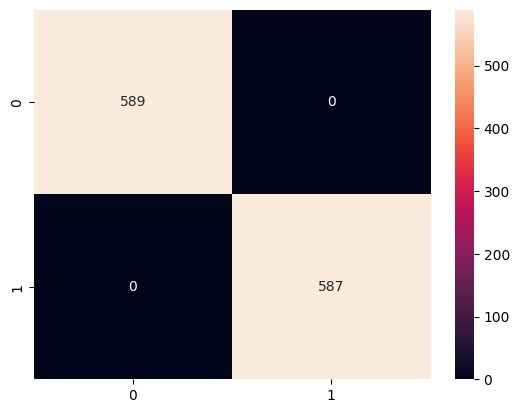

In [17]:
cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

In [19]:
importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Recency,0.863641
1,Frequency,0.073520
2,Monetary,0.062839


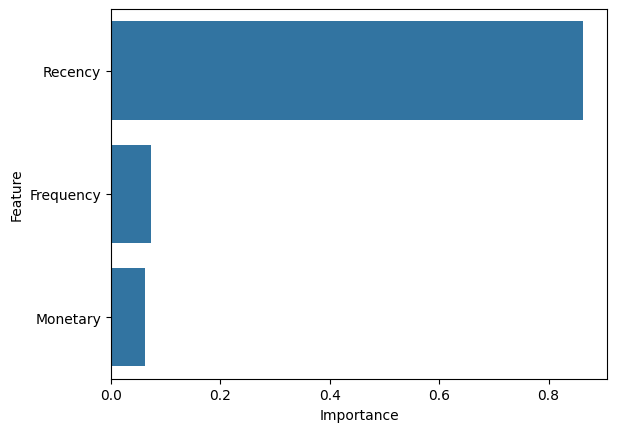

In [20]:
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.show()

In [21]:
customer_df["Churn_Prediction"] = (rf.predict(X))

In [22]:
customer_df.head()

,Recency,Frequency,Monetary,Churn,Churn_Prediction
Customer ID,,,,,
12346.0,325,12,77556.46,1,1
12347.0,1,8,5633.32,0,0
12348.0,74,5,2019.40,0,0
12349.0,18,4,4428.69,0,0
12350.0,309,1,334.40,1,1


In [23]:
high_risk = customer_df[ customer_df["Churn_Prediction"] == 1]

In [24]:
high_risk.head()

,Recency,Frequency,Monetary,Churn,Churn_Prediction
Customer ID,,,,,
12346.0,325,12,77556.46,1,1
12350.0,309,1,334.40,1,1
12351.0,374,1,300.93,1,1
12353.0,203,2,406.76,1,1
12354.0,231,1,1079.40,1,1


In [25]:
customer_df.to_csv(
    r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\processed\customer_churn.csv"
)

In [28]:
customer_df["Recency"]

Customer ID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
          ... 
18283.0      3
18284.0    431
18285.0    660
18286.0    476
18287.0     42
Name: Recency, Length: 5878, dtype: int64